# Machine Learning on the interface metrics
Created 2025-05-20

Final summary of all the machine learning performed to create an unified score for PPI

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import itertools
from typing import Literal

import matplotlib as mpl
from matplotlib.axes._axes import Axes
from matplotlib.figure import Figure
import matplotlib.patches

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import scipy

class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'


In [2]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_curve
import sklearn
import pickle
import re
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, auc

In [3]:
# Settings

# Path to resource folder with the structures and metadata tables
path_resources = Path(r"D:\Eigene Datein\dev\Uni\JGU Bio Bachelorthesis\Daten\resources")

path_AF2 = path_resources / "AF2"
path_AF3 = path_resources / "AF3_hydrogens"
path_solved = path_resources / "solved"

In [4]:
dataAF2 = pd.read_csv(path_AF2 / "AF2_metrics.tsv", sep="\t")
for c in ["chainA_start", "chainA_end", "chainB_start", "chainB_end", "num_mutations", "num_align_atoms_domain", "num_align_resi_domain", "hbonds", "salt_bridges", "hydrophobic_interactions"]:
    if c not in dataAF2.columns:
        print(f"Column {bcolors.FAIL}{c}{bcolors.ENDC} not (yet) in data frame")
        continue
    dataAF2[c] = dataAF2[c].astype(pd.Int64Dtype())
dataAF2["score_rank"] = dataAF2.groupby("prediction_name")["model_confidence"].rank("first", ascending=False).astype(pd.Int64Dtype())
dataAF2["RMSD_rank"] = dataAF2.groupby("prediction_name")["RMSD_all_atom"].rank("first").astype(pd.Int64Dtype())
dataAF2["RMSD_peptide_rank"] = dataAF2.groupby("prediction_name")["RMSD_all_atom_peptide"].rank("first").astype(pd.Int64Dtype())
dataAF2["DockQ_rank"] = dataAF2.groupby("prediction_name")["DockQ"].rank("first").astype(pd.Int64Dtype())
display(dataAF2)

,project_name,run_id,benchmark_set,prediction_name,model_id,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,buried_area,min_distance,disulfide_bonds,salt_bridges,hbonds,hydrophobic_interactions,score_rank,RMSD_rank,RMSD_peptide_rank,DockQ_rank
0,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,312,5,A,B,165,...,613.651,6.063,0.0,0,9,0,1,2,2,3
1,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,312,5,A,B,165,...,580.310,6.083,0.0,0,9,0,2,3,1,4
2,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,312,5,A,B,165,...,662.104,6.072,0.0,0,10,3,3,1,3,5
3,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,312,5,A,B,165,...,398.498,5.417,0.0,0,2,0,4,4,4,2
4,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,312,5,A,B,165,...,323.304,5.092,0.0,0,2,9,5,5,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3175,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,60,113,B,B,392,...,1617.382,5.591,0.0,3,7,56,1,1,<NA>,<NA>
3176,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,60,113,B,B,392,...,791.256,6.373,0.0,0,3,7,2,5,<NA>,<NA>
3177,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,60,113,B,B,392,...,882.547,7.906,0.0,1,2,11,3,4,<NA>,<NA>
3178,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,60,113,B,B,392,...,1020.896,4.628,0.0,3,7,44,4,3,<NA>,<NA>


In [5]:
dataAF3 = pd.read_csv(path_AF3 / f"{path_AF3.name}_metrics.tsv", sep="\t")
for c in ["chainA_start", "chainA_end", "chainB_start", "chainB_end", "num_mutations", "num_align_atoms_domain", "num_align_resi_domain", "hbonds", "salt_bridges", "hydrophobic_interactions"]:
    if c not in dataAF3.columns:
        print(f"Column {bcolors.FAIL}{c}{bcolors.ENDC} not (yet) in data frame")
        continue
    dataAF3[c] = dataAF3[c].astype(pd.Int64Dtype())
dataAF3["score_rank"] = dataAF3.groupby("prediction_name")["ranking_score"].rank("first", ascending=False).astype(pd.Int64Dtype())
dataAF3["RMSD_rank"] = dataAF3.groupby("prediction_name")["RMSD_all_atom"].rank("first").astype(pd.Int64Dtype())
dataAF3["RMSD_peptide_rank"] = dataAF3.groupby("prediction_name")["RMSD_all_atom_peptide"].rank("first").astype(pd.Int64Dtype())
dataAF3["DockQ_rank"] = dataAF3.groupby("prediction_name")["DockQ"].rank("first").astype(pd.Int64Dtype())
display(dataAF3)

,model_preset,benchmark_set,prediction_name,model_id,ranking_score,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,min_distance,disulfide_bonds,salt_bridges,hbonds,hydrophobic_interactions,ipSAE,score_rank,RMSD_rank,RMSD_peptide_rank,DockQ_rank
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,6.241,0,0,10,0,0.869025,1,2,1,5
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,6.207,0,0,11,0,0.868551,2,3,3,3
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,5.810,0,0,13,0,0.855837,3,5,4,1
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,6.264,0,0,11,0,0.850758,4,1,2,4
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,5.890,0,0,14,0,0.850449,5,4,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3175,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,5.367,0,2,1,0,0.012324,1,1,<NA>,<NA>
3176,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,6.907,0,2,2,15,0.000000,2,5,<NA>,<NA>
3177,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,6.442,0,2,4,0,0.000000,3,4,<NA>,<NA>
3178,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,4.914,0,1,2,48,0.000000,4,3,<NA>,<NA>


In [6]:
dataSolved = pd.read_csv(path_solved / "solved_hydrogens_metrics.tsv", sep="\t")
display(dataSolved)

,set,PDB_id,DDI_pfam_id,path,chainA_id,chainB_id,min_distance,buried_area,salt_bridges,hbonds,disulfide_bonds,hydrophobic_interactions
0,DMI,1ATP,NaN,DMI_hydrogens\1ATP_min_DMI.pdb,A,B,6.273,808.592,0,1,0,77
1,DMI,1AXC,NaN,DMI_hydrogens\1AXC_min_DMI.pdb,A,B,4.174,1209.332,0,4,0,62
2,DMI,1B72,NaN,DMI_hydrogens\1B72_min_DMI.pdb,A,B,5.182,547.149,0,1,0,36
3,DMI,1B8Q,NaN,DMI_hydrogens\1B8Q_min_DMI.pdb,A,B,4.376,871.756,0,4,0,42
4,DMI,1BXX,NaN,DMI_hydrogens\1BXX_min_DMI.pdb,A,B,4.435,783.465,0,6,0,19
...,...,...,...,...,...,...,...,...,...,...,...,...
183,DDI,3ZNI,PF14447_PF00179,DDI_hydrogens\PF14447_PF00179_3ZNI_AC.pdb,A,C,5.268,1288.881,0,10,0,85
184,DDI,3J7Y,PF14978_PF00327,DDI_hydrogens\PF14978_PF00327_3J7Y_oZ.pdb,o,Z,4.885,2488.556,0,8,0,70
185,DDI,6D6Q,PF15985_PF10175,DDI_hydrogens\PF15985_PF10175_6D6Q_GL.pdb,G,L,3.891,3659.160,1,12,0,167
186,DDI,3KZ1,PF17838_PF00071,DDI_hydrogens\PF17838_PF00071_3KZ1_BE.pdb,B,E,5.276,1249.398,2,10,0,60


In [7]:
dataAF = pd.merge(
    left=dataAF3,
    right=dataAF2,
    left_on=["benchmark_set", "prediction_name", "model_id"],
    right_on=["benchmark_set", "prediction_name", "model_id"],
    suffixes=["_AF3", "_AF2"],
    how="inner"
)
for c in ["chainA_length", "chainB_length", "chainA_id", "chainB_id", "chainA_start", "chainA_end", "chainB_start", "chainB_end", "PDB_id", "ELM_instance", "DDI_pfam_id", "PDB_id_random_paired", "ELM_instance_random_paired", "DDI_pfam_id_random_paired", "sequence_initial", "sequence_mutated", "num_mutations", "score_rank"]:
    if len(dataAF[~(dataAF[c+"_AF2"] == dataAF[c+"_AF3"]) & (~dataAF[c+"_AF2"].isna()) & (~dataAF[c+"_AF3"].isna())]) > 0:
        print(f"Unmatched column {c}")
        continue
    dataAF.drop(columns=[c+"_AF2"], inplace=True)
    dataAF.rename(columns={c+"_AF3": c}, inplace=True)
dataAF.rename(columns={"ranking_score": "ranking_score_AF3"}, inplace=True)
dataAF.rename(columns={"model_confidence": "model_confidence_AF2"}, inplace=True)
dataAF.rename(columns={"ipSAE": "ipSAE_AF3"}, inplace=True)

display(dataAF)

,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,Fnonnat_AF2,buried_area_AF2,min_distance_AF2,disulfide_bonds_AF2,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,0.086957,613.651,6.063,0.0,0,9,0,2,2,3
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,0.050000,580.310,6.083,0.0,0,9,0,3,1,4
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,0.185185,662.104,6.072,0.0,0,10,3,1,3,5
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,0.363636,398.498,5.417,0.0,0,2,0,4,4,2
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,0.888889,323.304,5.092,0.0,0,2,9,5,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3165,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,NaN,1617.382,5.591,0.0,3,7,56,1,<NA>,<NA>
3166,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,NaN,791.256,6.373,0.0,0,3,7,5,<NA>,<NA>
3167,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,NaN,882.547,7.906,0.0,1,2,11,4,<NA>,<NA>
3168,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,NaN,1020.896,4.628,0.0,3,7,44,3,<NA>,<NA>


In [78]:
general_training_columns = ["chainA_length", "chainB_length"]
intf_metrics_columns = ["buried_area", "min_distance", "salt_bridges", "hbonds", "hydrophobic_interactions"]
af_metrics_columns = ["intf_avg_plddt", "num_chainA_intf_res", "num_chainB_intf_res", "num_res_res_contact", "iPAE", "pDockQ"]
extended_af_metrics_columns = ["chainA_intf_avg_plddt", "chainB_intf_avg_plddt", "num_atom_atom_contact"]

af2_intf = general_training_columns + [v+"_AF2" for v in intf_metrics_columns] + ["num_res_res_contact_AF2"]
af3_intf = general_training_columns + [v+"_AF3" for v in intf_metrics_columns] + ["num_res_res_contact_AF3"]
af2_columns1 = general_training_columns + ["model_confidence_AF2"] + [v+"_AF2" for v in af_metrics_columns] + [v+"_AF2" for v in intf_metrics_columns]
af3_columns1 = general_training_columns + ["ranking_score_AF3"] + [v+"_AF3" for v in af_metrics_columns] + [v+"_AF3" for v in intf_metrics_columns]

In [190]:
pdb_train, pdb_test = train_test_split(sorted(list(set(dataAF[dataAF["benchmark_set"] == "known_DMI"]["PDB_id"]))), random_state=2502)

def get_train_test(af_v: Literal["AF2", "AF3"], benchmark_sets: list[str], rank_filter: None|Literal["best_ranked", "RMSD", "RMSD_peptide", "DockQ"]):
    data_mask = dataAF["benchmark_set"].isin(benchmark_sets)
    if rank_filter == "best_ranked":
        data_mask &= (dataAF[f"score_rank"] == 1)
    elif rank_filter is not None:
        data_mask &= (dataAF[f"{rank_filter}_rank_{af_v}"] == 1)

    train = dataAF[data_mask & (dataAF["PDB_id"].isin(pdb_train)) & (dataAF["PDB_id_random_paired"].isna() | dataAF["PDB_id_random_paired"].isin(pdb_train))].sample(frac=1, random_state=2501)
    test = dataAF[data_mask & (~dataAF["PDB_id"].isin(pdb_train)) & (dataAF["PDB_id_random_paired"].isna() | ~dataAF["PDB_id_random_paired"].isin(pdb_train))].sample(frac=1, random_state=2501)
    print(f"Train {len(train)}, test {len(test)}")
    return train, test

In [10]:
# Stop cell designed to crash to allow "Run All" command in Jupyter notebooks to stop here
raise Exception("STOP")

Exception: STOP

### 1 ML plot

Train 865, test 235


RandomForestClassifier(class_weight='balanced', min_impurity_decrease=0.005,
                       random_state=2501)

Train score: 0.824
Test score: 0.677
Test AUROC: 0.751
Test sample: 170 / 235 true


RandomForestClassifier(class_weight='balanced', min_impurity_decrease=0.001,
                       random_state=2501)

Train score: 0.982
Test score: 0.740
Test AUROC: 0.820
Test sample: 170 / 235 true
Train 510, test 170


RandomForestClassifier(class_weight='balanced', random_state=2501)

Train score: 1.000
Test score: 0.553
Test AUROC: 0.626
Test sample: 83 / 170 true
Train 102, test 34


C:\Users\abril\AppData\Local\Temp\ipykernel_291268\2917544043.py:92: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train.fillna(value=10.0, inplace=True)
C:\Users\abril\AppData\Local\Temp\ipykernel_291268\2917544043.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test.fillna(value=10.0, inplace=True)


LinearRegression()

Train score: 0.194
Test score: 0.052


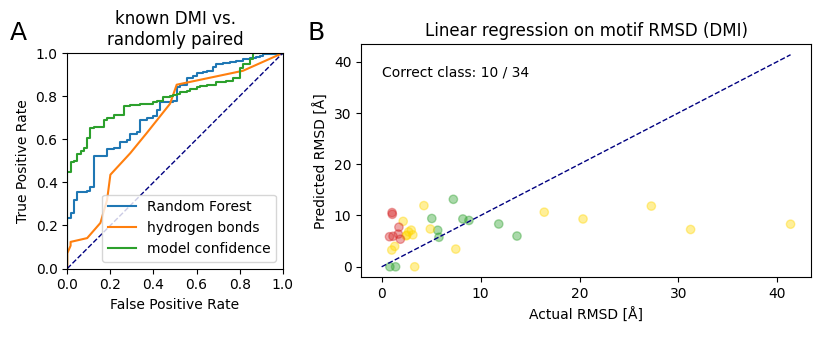

In [200]:
def plot_roc(ax:Axes, trees: dict[str, tuple]):
    for label, (tr, fa, reverse) in trees.items():
        y_true = [1]*len(tr) + [0]*len(fa) if not reverse else [0]*len(tr) + [1]*len(fa)
        y_score = tr.tolist() + fa.tolist()
        ax.plot(*roc_curve(y_true, y_score)[0:2], label=label)
    ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_aspect(1)
    ax.set_xlabel('False Positive Rate\n')
    ax.set_ylabel('True Positive Rate')
    ax.legend()

def plot_prediction(ax:Axes, y_true, y_score, title, text = None):
    class_diff_array = np.abs(get_class(y_true)-get_class(y_score))
    c = np.select([class_diff_array==0, class_diff_array==1, class_diff_array>1], ["tab:green", "gold", "tab:red"])
    ax.scatter(y_true, y_score, c=c, alpha=0.4)
    ax.set_xlabel(f"Actual RMSD [Å]")
    ax.set_ylabel(f"Predicted RMSD [Å]")
    ax.set_title(title)
    max_ = np.max([y_true, y_score])
    ax.plot([0, max_], [0, max_], color='navy', lw=1, linestyle='--')
    if text is not None:
        ax.text(0.05, 0.95*max_, text, verticalalignment="top")


def train_rf(train, test, X_columns, train_y, test_y, test_true_mask, min_impurity_decrease: float):
    rf = RandomForestClassifier(random_state=2501, min_impurity_decrease=min_impurity_decrease, class_weight="balanced").fit(train[X_columns], train_y)
    display(rf)
    print(f"Train score: {rf.score(train[X_columns], train_y):1.3f}" )
    print(f"Test score: {rf.score(test[X_columns], test_y):1.3f}" )
    print(f"Test AUROC: {roc_auc_score(test_true_mask, rf.predict_proba(test[X_columns])[:,0]):1.3f}" )

    tr = rf.predict_proba(test[test_true_mask][X_columns])[:,0]
    fa = rf.predict_proba(test[~test_true_mask][X_columns])[:,0]
    print(f"Test sample: {np.count_nonzero(test_true_mask)} / {len(test)} true")

    return (tr, fa)

def train_linear_regression(train, test, X_columns, train_y, test_y):
    lr = LinearRegression().fit(train[X_columns], train_y)
    display(lr)
    print(f"Train score: {lr.score(train[X_columns], train_y):1.3f}")
    print(f"Test score: {lr.score(test[X_columns], test_y):1.3f}")

    return lr.predict(test[X_columns])

def train_lasso_regression(train, test, X_columns, train_y, test_y, alpha):
    lr = Lasso(alpha=alpha).fit(train[X_columns], train_y)
    display(lr)
    print(f"Train score: {lr.score(train[X_columns], train_y):1.3f}")
    print(f"Test score: {lr.score(test[X_columns], test_y):1.3f}")

    return lr.predict(test[X_columns])

fig, axes = plt.subplots(1, 3, figsize=(9,3.3))

trees = {}
train, test = get_train_test(af_v="AF2", benchmark_sets=["known_DMI", "random_DMI"], rank_filter=None, )
tr, fa = train_rf(train, test, X_columns=af2_intf, min_impurity_decrease=0.005, train_y=train["benchmark_set"], test_y=test["benchmark_set"], test_true_mask=(test["benchmark_set"] == "known_DMI"))
trees["Random Forest"] = (tr, fa, False)

tr, fa = test[test["benchmark_set"] == "known_DMI"]["hbonds_AF2"], test[test["benchmark_set"] == "random_DMI"]["hbonds_AF2"]
tr, fa = train_rf(train, test, X_columns=af2_columns1, min_impurity_decrease=0.001, train_y=train["benchmark_set"], test_y=test["benchmark_set"], test_true_mask=(test["benchmark_set"] == "known_DMI"))
#trees["RF all metrics"] = (tr, fa, False)

tr, fa = test[test["benchmark_set"] == "known_DMI"]["hbonds_AF2"], test[test["benchmark_set"] == "random_DMI"]["hbonds_AF2"]
trees["hydrogen bonds"] = (tr, fa, False)

tr, fa = test[test["benchmark_set"] == "known_DMI"]["model_confidence_AF2"], test[test["benchmark_set"] == "random_DMI"]["model_confidence_AF2"]
trees["model confidence"] = (tr, fa, False)

train, test = get_train_test(af_v="AF2", benchmark_sets=["known_DMI"], rank_filter=None, )
tr, fa = train_rf(train, test, X_columns=af2_intf, min_impurity_decrease=0.0, train_y=(train["RMSD_all_atom_peptide_AF2"] < 5), test_y=(test["RMSD_all_atom_peptide_AF2"] < 5), test_true_mask=~(test["RMSD_all_atom_peptide_AF2"] < 5))
#trees["known DMI < 5 A"] = (tr, fa, False)

#sns.set_theme()

plot_roc(axes[0],trees=trees)
axes[0].set_title("known DMI vs.\nrandomly paired")


# Linear regression

def get_class(rmsd: float|np.ndarray):
    rmsd = np.array(rmsd)
    # Nice trick to assign classes based on cutoff values, as
    # <2 --> 0; 2-5 --> 1; 5-15 --> 2; >=15 --> 3 
    return (rmsd >= 2).astype(int) + (rmsd >= 5).astype(int) + (rmsd >= 15).astype(int)

train, test = get_train_test(af_v="AF2", benchmark_sets=["known_DMI"], rank_filter="best_ranked")
train.fillna(value=10.0, inplace=True)
test.fillna(value=10.0, inplace=True)
y_true = test["RMSD_all_atom_peptide_AF2"]
y_score = train_linear_regression(train, test, X_columns=af2_intf, train_y=train["RMSD_all_atom_peptide_AF2"], test_y=y_true)
y_score = np.clip(y_score, a_min=0, a_max=None)
text = f"Correct class: {np.count_nonzero(get_class(y_true) == get_class(y_score))} / {len(y_true)}"
plot_prediction(axes[1], y_true=y_true, y_score=y_score, title="Linear regression on motif RMSD (DMI)", text=text)


# y_true = test["RMSD_all_atom_peptide_AF3"]
# y_score = train_linear_regression(train, test, X_columns=af3_intf, train_y=train["RMSD_all_atom_peptide_AF3"], test_y=y_true)
# y_score = np.clip(y_score, a_min=0, a_max=None)
# text = f"Correct class: {np.count_nonzero(get_class(y_true) == get_class(y_score))} / {len(y_true)}"
# plot_prediction(axes[2], y_true=y_true, y_score=y_score, title="Lasso regression on\nmotif RMSD (DMI)", text=text)

fig.tight_layout()
fig.text(0.01, 0.9, "A", fontsize=18)
fig.text(0.34, 0.9, "B", fontsize=18)
#fig.text(0.67, 0.92, "C", fontsize=18)
ax1_pos = axes[1].get_position()
ax1_pos.x1 = 0.9
axes[1].set_position(ax1_pos)
axes[2].set_visible(False)
plt.savefig(f"./plots/machine_learning.png", bbox_inches='tight', dpi=600)
plt.show()

### 2 Prediction of motif RMSD

In [122]:
get_class(y_true)-get_class(y_score)

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

In [124]:
get_class(y_score)

array([ True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True, False,  True,  True,
       False,  True,  True, False,  True,  True,  True, False,  True,
        True,  True,  True,  True, False,  True,  True])